In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'Untitled form (2).gform',
 'Untitled form (1).gform',
 'Untitled form.gform',
 'HARIOM NURSERY.pdf',
 '17030888708685629955602248902668.jpg',
 'IMG-20240105-WA0001.jpg',
 'IMG-20240213-WA0000.jpg',
 'NIMCET RESULT.pdf',
 '3 ROUND SEAT ALLOTEMENT LETTER.pdf',
 'IMG-20240730-WA0007.jpg',
 'Screenshot_2024-08-12-22-34-53-18_6012fa4d4ddec268fc5c7112cbb265e7.jpg',
 '24204031225_Hardik vishwakarma_1.txt',
 '24204031225_Hardik vishwakarma_2.txt',
 '24204031225_Hardik vishwakarma_3.txt',
 '24204031225_Hardik vishwakarma_4.txt',
 '24204031225_Hardik vishwakarma_5.txt',
 '24204031225_Hardik vishwakarma_6.txt',
 '24204031225_Hardik vishwakarma_7.txt',
 '24204031225_Hardik vishwakarma_8 (1).txt',
 '24204031225_Hardik vishwakarma_10.txt',
 '24204031225_Hardik vishwakarma_9.txt',
 '24204031225_Hardik vishwakarma_8.txt',
 'Screenshot_2024-12-11-10-53-47-89_6012fa4d4ddec268fc5c7112cbb265e7.jpg',
 'DFD Diagram.drawio',
 'assignment-2 ada.pdf',
 'assignment-1 ada.pdf',
 'Resume',
 

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

In [ ]:
dataset_path = "/content/dataset"

for folder in os.listdir(dataset_path):
    print(folder)

rosacea.1054.jpg
milia.43.jpg
acne.0.jpg
carcinoma.23.jpg
acne.112.jpg
rosacea.84.jpg
acne.444.jpg
keratosis.158.jpg
carcinoma.140.jpg
milia.30.jpg
acne.231.jpg
keratosis.143.jpg
acne.523.jpg
keratosis.21.jpg
rosacea.304.jpg
rosacea.712.jpg
rosacea.472.jpg
keratosis.149.jpg
rosacea.1053.jpg
rosacea.93.jpg
eczema.1131.jpg
eczema.213.jpg
acne.1152.jpg
milia.87.jpg
milia.106.jpg
carcinoma.113.jpg
eczema.192.jpg
rosacea.821.jpg
carcinoma.51.jpg
eczema.424.jpg
keratosis.26.jpg
rosacea.612.jpg
carcinoma.73.jpg
acne.03.jpg
carcinoma.9.jpg
eczema.954.jpg
keratosis.52.jpg
eczema.1172.jpg
rosacea.94.jpg
rosacea.124.jpg
acne.1123.jpg
acne.294.jpg
acne.1223.jpg
rosacea.734.jpg
rosacea.701.jpg
keratosis.141.jpg
acne.1064.jpg
keratosis.94.jpg
rosacea.593.jpg
carcinoma.67.jpg
carcinoma.142.jpg
eczema.683.jpg
acne.34.jpg
rosacea.923.jpg
acne.1182.jpg
keratosis.20.jpg
eczema.771.jpg
acne.874.jpg
acne.371.jpg
carcinoma.157.jpg
rosacea.563.jpg
acne.852.jpg
eczema.1103.jpg
acne.1191.jpg
keratosis.10.jpg
r

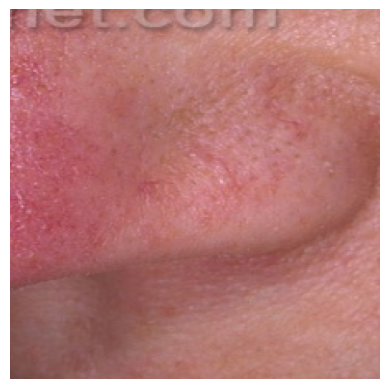

In [ ]:
import cv2
import matplotlib.pyplot as plt

img_path = "/content/dataset/rosacea.184.jpg"

img = cv2.imread(img_path)
img = cv2.resize(img,(224,224))

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
dataset_path = "/content/dataset"

files = os.listdir(dataset_path)

print("Total Images:", len(files))
print(files[:10])

Total Images: 1399
['rosacea.1054.jpg', 'milia.43.jpg', 'acne.0.jpg', 'carcinoma.23.jpg', 'acne.112.jpg', 'rosacea.84.jpg', 'acne.444.jpg', 'keratosis.158.jpg', 'carcinoma.140.jpg', 'milia.30.jpg']


In [ ]:
images = []
labels = []

for file in files:

    img_path = dataset_path + "/" + file

    img = cv2.imread(img_path)
    img = cv2.resize(img,(224,224))

    images.append(img)

    label = file.split(".")[0]
    labels.append(label)

In [ ]:
images = np.array(images)

print(images.shape)

(1399, 224, 224, 3)


In [ ]:
images = images / 255.0

In [ ]:
from tensorflow.keras.applications import VGG16

model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
features = model.predict(images)

print(features.shape)

44/44 ━━━━━━━━━━━━━━━━━━━━ 30s 394ms/step
(1399, 7, 7, 512)


In [ ]:
features = features.reshape(features.shape[0], -1)

print(features.shape)

(1399, 25088)


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

labels_encoded = encoder.fit_transform(labels)

print(labels_encoded[:10])

[5 4 0 1 0 5 0 3 1 4]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels_encoded,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.svm import SVC

classifier = SVC(kernel='linear')

classifier.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
accuracy = classifier.score(X_test, y_test)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.7892857142857143


In [ ]:
test_img = cv2.imread("/content/dataset/rosacea.184.jpg")
test_img = cv2.resize(test_img,(224,224))

test_img = test_img / 255.0

test_img = np.expand_dims(test_img, axis=0)

test_feature = model.predict(test_img)

test_feature = test_feature.reshape(1,-1)

prediction = classifier.predict(test_feature)

print("Predicted class:", encoder.inverse_transform(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted class: ['rosacea']
